# 04 — District Capacity Index and Inequality Analysis

WHO SDG 3.c.1-style clinical workforce density (doctors + nurses + midwives per 10,000 population) per kabupaten, and whether flood disruption hit underserved districts harder. Full discussion in `../docs/phase2_summary.md` and `../docs/sentinel1_validated_results.md`.

In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PROC = Path('../data/processed')
capacity = gpd.read_file(DATA_PROC / 'kabupaten_capacity_index.geojson')
capacity[['kabupaten', 'population_2020', 'clinical_staff', 'clinical_staff_per_10k', 'capacity_class']]\
    .sort_values('clinical_staff_per_10k')

,kabupaten,population_2020,clinical_staff,clinical_staff_per_10k,capacity_class
3,Barito Kuala,331247.750000,816,24.634130,underserved
1,Kotabaru,400543.406250,997,24.891185,underserved
2,Banjar,648102.812500,1954,30.149537,underserved
0,Tanah Laut,396134.531250,1248,31.504449,underserved
4,Tapin,231151.375000,764,33.051934,underserved
8,Tabalong,276634.531250,958,34.630528,underserved
9,Tanah Bumbu,387199.968750,1535,39.643598,well-served
7,Hulu Sungai Utara,209030.562500,857,40.998789,well-served
6,Hulu Sungai Tengah,262395.250000,1077,41.044950,well-served
12,Kota Banjarbaru,286467.406250,1247,43.530258,well-served


## Capacity choropleth

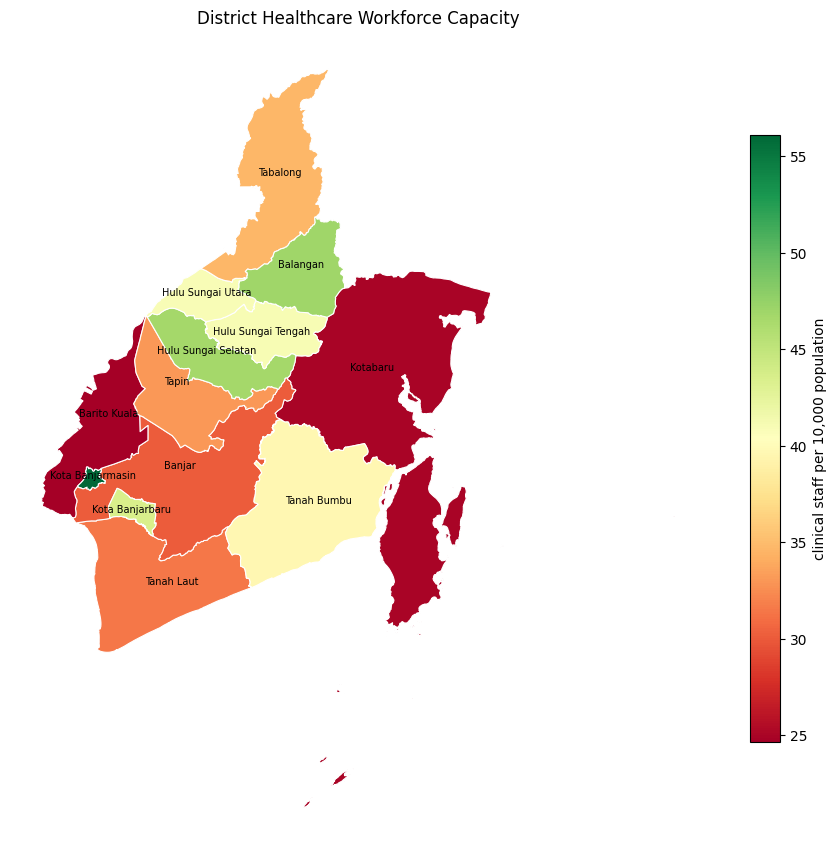

In [2]:
fig, ax = plt.subplots(figsize=(9, 9))
capacity.plot(ax=ax, column='clinical_staff_per_10k', cmap='RdYlGn', legend=True,
              edgecolor='white', linewidth=0.8,
              legend_kwds={'label': 'clinical staff per 10,000 population', 'shrink': 0.7})
for _, row in capacity.iterrows():
    c = row.geometry.representative_point()
    ax.annotate(row['kabupaten'], (c.x, c.y), fontsize=7, ha='center')
ax.set_title('District Healthcare Workforce Capacity')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Inequality: access change by capacity, real (Sentinel-1) disruption

In [3]:
per_kab = pd.read_csv(DATA_PROC / 'inequality_per_kabupaten.csv')
per_kab = per_kab.sort_values('clinical_staff_per_10k')
per_kab

,kabupaten,capacity_class,clinical_staff_per_10k,total_pop,baseline_pct_within60,s1_moderate_pct_within60,s1_severe_pct_within60,proxy_moderate_pct_within60,proxy_severe_pct_within60,pp_drop_s1_moderate,pp_drop_proxy_moderate
0,Barito Kuala,underserved,24.634130,335245.734326,88.730802,78.503369,0.000000,78.700025,0.000000,10.227433,10.030777
1,Kotabaru,underserved,24.891185,394950.719092,24.686137,24.505892,21.289349,22.765597,0.704757,0.180245,1.920540
2,Banjar,underserved,30.149537,653656.817750,80.904920,76.760973,0.000000,78.618193,32.567317,4.143947,2.286728
3,Tanah Laut,underserved,31.504449,395275.808604,84.290096,84.128824,0.000000,83.960322,8.757407,0.161272,0.329775
4,Tapin,underserved,33.051934,230926.583305,83.994772,83.462504,0.000000,81.951578,62.410018,0.532268,2.043194
5,Tabalong,underserved,34.630528,276662.041940,76.923110,76.863394,0.000000,76.923110,13.602280,0.059716,0.000000
6,Tanah Bumbu,well-served,39.643598,385854.173109,75.470459,74.715435,37.775036,73.976497,1.291100,0.755024,1.493962
7,Hulu Sungai Utara,well-served,40.998789,208528.705161,83.042056,83.042056,0.000000,83.042056,0.827214,0.000000,0.000000
8,Hulu Sungai Tengah,well-served,41.044950,262585.384534,96.478428,95.543478,0.000000,96.478428,80.109462,0.934951,0.000000
9,Kota Banjarbaru,well-served,43.530258,283021.054751,99.976453,99.976453,0.000000,99.976453,88.875846,0.000000,0.000000


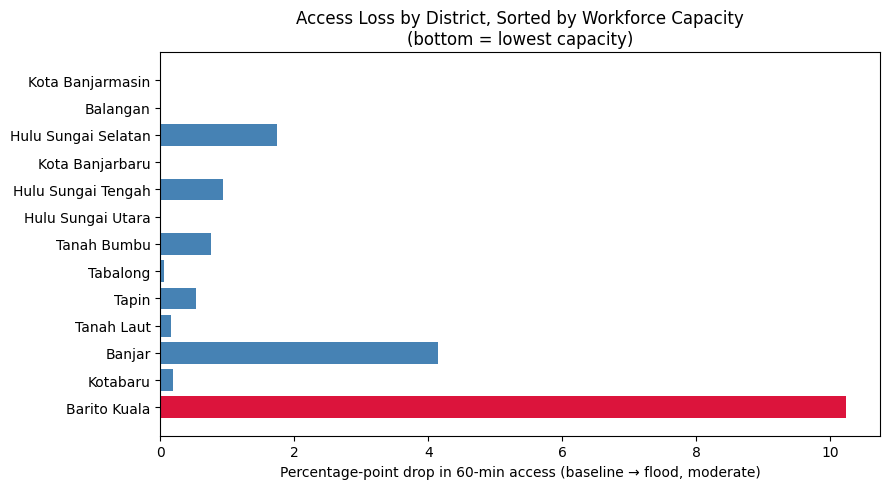

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if d > 10 else 'steelblue' for d in per_kab['pp_drop_s1_moderate']]
ax.barh(per_kab['kabupaten'], per_kab['pp_drop_s1_moderate'], color=colors)
ax.set_xlabel('Percentage-point drop in 60-min access (baseline → flood, moderate)')
ax.set_title('Access Loss by District, Sorted by Workforce Capacity\n(bottom = lowest capacity)')
plt.tight_layout()
plt.show()

## Capacity vs. access loss — correlation check

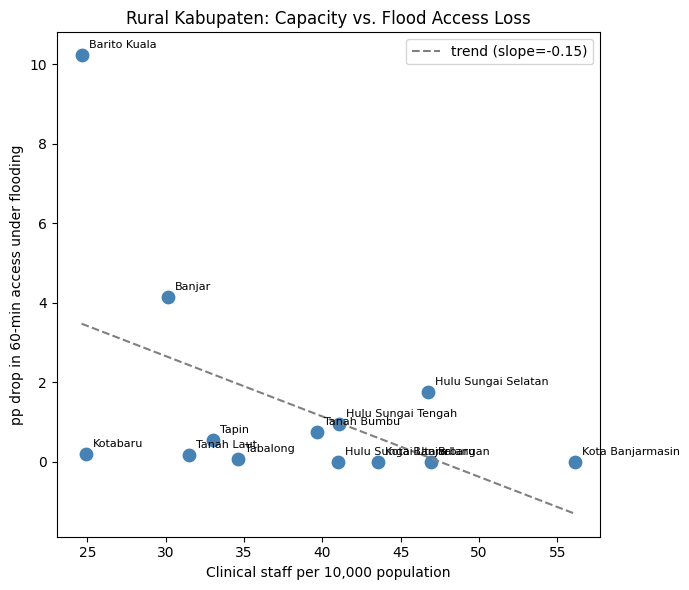

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(per_kab['clinical_staff_per_10k'], per_kab['pp_drop_s1_moderate'], s=80, color='steelblue')
for _, row in per_kab.iterrows():
    ax.annotate(row['kabupaten'], (row['clinical_staff_per_10k'], row['pp_drop_s1_moderate']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')
z = np.polyfit(per_kab['clinical_staff_per_10k'], per_kab['pp_drop_s1_moderate'], 1)
xs = np.linspace(per_kab['clinical_staff_per_10k'].min(), per_kab['clinical_staff_per_10k'].max(), 50)
ax.plot(xs, np.poly1d(z)(xs), '--', color='gray', label=f'trend (slope={z[0]:.2f})')
ax.set_xlabel('Clinical staff per 10,000 population')
ax.set_ylabel('pp drop in 60-min access under flooding')
ax.set_title('Rural Kabupaten: Capacity vs. Flood Access Loss')
ax.legend()
plt.tight_layout()
plt.show()